# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, models
import tensorflow as tf
from tensorflow.keras.utils import PyDataset
from itertools import combinations
import shutil

!pip install gdown -q
import gdown
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [39]:
BATCH_SIZE = 64
N_PATCHES  = 9
GRID       = 3            # 3x3 grid
CELL       = 32          # each grid cell is 32x32
CROP       = 28          # patch is 28x28 (centered in the 32x32 cell)
MARGIN     = (CELL - CROP) // 2   # 2 px erosion border per side
IMG        = 96          # full image 96x96
EMBED_DIM  = 256

FILE_ID_Phase1 = "1agicv7JVnZVkHwiYRwhN5_0c9LzMfwdG"
FILE_ID_Final = "1TCJLGXenRdDwMHhJ4dzHuK1oVErOMDLz"

# Relative Position Label Setup

For the pairwise direction auxiliary loss we need two things: a fixed list of
all patch pairs, and a way to compute the direction label for any two grid positions.

With 9 patches there are C(9,2) = 36 unique unordered pairs. We fix their order
once so the labels are consistent across every batch and every epoch. `PAIRS[j]`
always refers to the same two slots, and `Yrel[j]` always carries the direction
label for that pair.

For the direction itself, we only care about the sign of the row and column
difference between the two true grid positions, not the actual distance. So a
patch two cells above another and a patch one cell above get the same label.
This collapses the problem to 8 compass directions (the 9th combination, (0,0),
would mean the same patch twice, which never happens for distinct pairs).

`rel_label(pos_a, pos_b)` takes two absolute grid positions (0-8),
computes the row and column of each via `divmod`, takes the sign of the difference,
and looks up the direction class. This is called once per pair per image inside
the generator.

Relative direction supervision follows the pairwise auxiliary task proposed in:

> Zhao, Q., & Dong, J. (2020). *Self-supervised Representation Learning by Predicting Visual Permutations.*

In [40]:
# 36 unordered patch-slot pairs, fixed order
PAIRS  = list(combinations(range(9), 2))
PAIR_A = [a for a, b in PAIRS]          # first slot of each pair
PAIR_B = [b for a, b in PAIRS]          # second slot of each pair

# (sign_drow, sign_dcol) -> direction class 0..7
DIRECTION_MAP = {}
_idx = 0
for _dr in (-1, 0, 1):
    for _dc in (-1, 0, 1):
        if _dr == 0 and _dc == 0:
            continue
        DIRECTION_MAP[(_dr, _dc)] = _idx
        _idx += 1

def rel_label(pos_a, pos_b):
    ra, ca = divmod(int(pos_a), 3)
    rb, cb = divmod(int(pos_b), 3)
    dr = int(np.sign(rb - ra))
    dc = int(np.sign(cb - ca))
    return DIRECTION_MAP[(dr, dc)]

## Data Generator and Training Labels

The Patch generator handles loading, normalising, patch extraction, scrambling, and
label generation in one place. A few things changes made in the generator function:

- `Random Horizontal flip` Early in training I noticed a
gap between training and validation positioning accuracy, around 0.93 train vs
0.79 val. The model was learning specific images rather
than general positioning rules. To overcome the overfittting of the model on the training images, horizontal flips are applied at random to the images in training set.

  The flip is applied to the full image *before* patch extraction, so X, Y, the
  permutation labels, and the direction labels are all derived from the same flipped
  image and stay internally consistent. Validation and test generators never flip as evaluation needs to be deterministic.

- `perm_logits` Training on image reconstruction MAE alone reached only 0.059 after 50 epochs. Adding
per-slot absolute position labels (perm_logits) provides a direct cross-entropy
signal to the transformer, reaching a better result in under 10 epochs. These
labels are used only during training and not for prediction of the shuffled test patches.

- `rel_logits` The relative direction labels (rel_logits) encode the direction between
each of the 36 patch pairs. This is useful for ambiguous patches like animal textures. It is introduced in Phase 2
rather than from the start to avoid gradient conflicts during early training.

In [41]:
def get_stl10_memmap():
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )
    base_dir = os.path.dirname(path)
    filepath = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary', 'unlabeled_X.bin')

    # STL-10: 100,000 images, 3 channels, 96x96
    # We use memmap to avoid loading the file into RAM
    # Shape is (N, C, H, W) based on STL-10 binary format
    shape = (100000, 3, 96, 96)
    images_mmap = np.memmap(filepath, dtype='uint8', mode='r', shape=shape)

    return images_mmap

class PatchGenerator(PyDataset):
    def __init__(self, images_mmap, batch_size=32, patch_size=32, crop_size=28, shuffle=True, flip = False, **kwargs):
        super().__init__(**kwargs)
        # Store the pointer to the memmap, keep it as uint8
        self.images = images_mmap
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.flip = flip
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")
        Ypos = np.zeros((actual_batch_size, 9), dtype="int32")
        Yrel = np.zeros((actual_batch_size, 36), dtype="int32")

        for i, img_idx in enumerate(batch_indices):
            # 1. Load from disk/cache only what we need
            # 2. Transpose from (C, H, W) to (H, W, C)
            # 3. Convert to float and normalize ONLY this one image
            img_cxhxw = self.images[img_idx]
            full_img = img_cxhxw.transpose(2, 1, 0).astype("float32") / 255.0
            if self.flip and np.random.rand()>0.5:
              full_img = np.fliplr(full_img)

            Y[i] = full_img

            # Patch extraction logic
            patches = []
            for r in range(3):
                for c in range(3):
                    y_s, x_s = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_s:y_s+self.patch_size, x_s:x_s+self.patch_size, :]

                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin:margin+self.crop_size, margin:margin+self.crop_size, :]
                    patches.append(patch)

            order = np.random.permutation(9)
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]
                Ypos[i, slot_idx] = original_pos

            for j, (a, b) in enumerate(PAIRS):
              Yrel[i, j] = rel_label(order[a], order[b])


        return X, {"reconstruction": Y, "perm_logits": Ypos, "rel_logits": Yrel}

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [42]:
# Trigger the download and loading
images = get_stl10_memmap()
print(f"Successfully downloaded and memory mapped {images.shape[0]} images.")

Successfully downloaded and memory mapped 100000 images.


In [43]:
print(images.shape)

(100000, 3, 96, 96)


In [44]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [45]:
train_generator = PatchGenerator(train_images, batch_size=BATCH_SIZE, flip = True)
val_generator = PatchGenerator(val_images, batch_size=BATCH_SIZE, shuffle = False)
test_generator = PatchGenerator(test_images, batch_size=BATCH_SIZE, shuffle = True)

In [46]:
print(len(train_generator))

1250


Let us inspect the dataset.

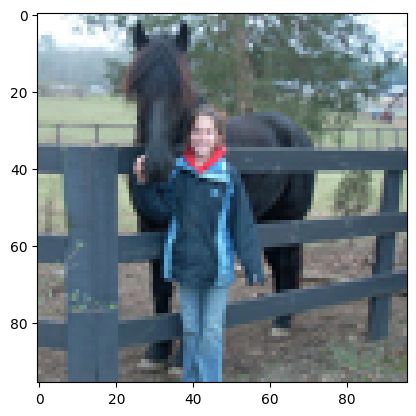

In [47]:
n = np.random.randint(0,test_images.shape[0])
plt.imshow(np.transpose(test_images[n],(2,1,0)))

Let us now visualize the puzzle

In [48]:
def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * CELL) + MARGIN
        y_end = y_start + CROP
        x_start = (col * CELL) + MARGIN
        x_end = x_start + CROP

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [49]:
a,b = test_generator.__getitem__(1)

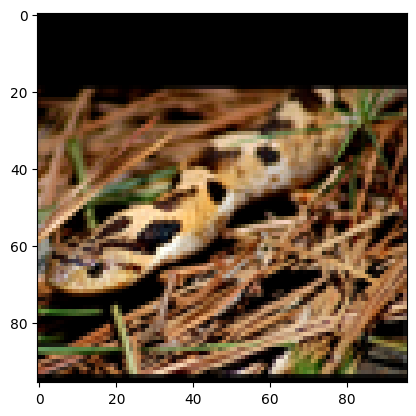

In [50]:
plt.imshow(b['reconstruction'][4])

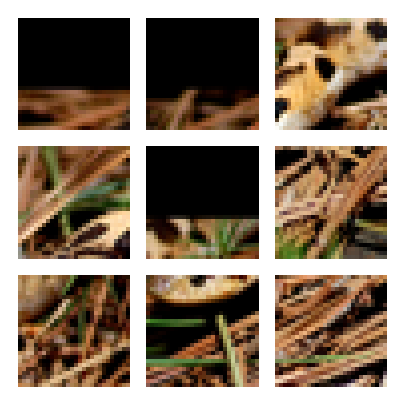

In [51]:
plot_puzzle(a[4])

As an indicative baseline, let us compute the MAE relative to the mean patches.

In [52]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [53]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b['reconstruction']))
baseline_MAE = tf.reduce_mean(mae_values)
baseline_std = tf.math.reduce_std(mae_values)
print("MAE:", baseline_MAE)
print("std:", baseline_std)

MAE: tf.Tensor(0.18236725, shape=(), dtype=float32)
std: tf.Tensor(0.00072068966, shape=(), dtype=float32)


# Pixel Mask

Since each patch is centre-cropped from a 32×32 cell down to 28×28, placing
patches back onto the canvas leaves a 2px gap around every cell.

When patches are placed back onto the 96×96 canvas,
this creates a regular grid of gaps:

- **4px-wide gaps** between adjacent cells (2px from each side)
- **2px outer border** around the full image

The mask just encodes this geometry: 1 where there is a patch pixel, 0 everywhere
else. It is the same for every single image in the dataset since it depends
only on the 3×3 grid structure, not on image content.

This mask serves two purposes:
1. It gets concatenated to the canvas as a 4th channel
so the U-Net can tell the difference between pixels it received (which are
reliable) and pixels it needs to fill in (which are zero)
2. It is used
in the final compose step so that correctly placed patch pixels pass through
untouched thus contributing very less error to the MAE on 76.5% of the image (the part covered by patches).


In [54]:
def build_mask():
    m = np.zeros((IMG, IMG, 1), dtype="float32")
    for p in range(N_PATCHES):
        r, c = p // GRID, p % GRID
        top  = r * CELL + MARGIN
        left = c * CELL + MARGIN
        m[top:top + CROP, left:left + CROP, :] = 1.0
    return m

MASK_NP = build_mask()
MASK    = tf.constant(MASK_NP[None], dtype="float32")   # (1, 96, 96, 1)

# Patch Encoder

Each of the 9 shuffled patches is encoded independently by a **shared CNN**
into a 256-dimensional feature vector.
This means that the same set of parameters
is applied to all 9 patches. For the encoder, a stack of Conv2D layers that progressively reduce spatial size
while increasing channel depth, ending in a Flatten and Dense projection was used.

The encoder is applied to all 9 patches by calling the same model object 9 times
in a loop.

In [55]:
def build_patch_encoder(embed_dim=EMBED_DIM):
    inp = keras.Input(shape=(CROP, CROP, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)        # 28
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)   # 14
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)   # 7
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)  # 4
    x = layers.Flatten()(x)
    x = layers.Dense(embed_dim, activation="relu")(x)
    return keras.Model(inp, x, name="patch_encoder")

# Transformer Block

After encoding, each patch is a 256-dim token. On their own, these tokens only
describe individual patch content. The transformer lets each patch **look at all
other patches** and update its representation based on what it finds.

**Reasoning behind using the transformer:** A patch of sky cannot know it belongs at
the top just from its own content. It needs to see that the other patches contain
ground, sides, and object content. After 3 transformer blocks, the sky patch token
encodes not just "I am sky" but "I am sky, the others are ground and sides,
therefore I belong in the top row."

No positional encoding is added. The input slot order is arbitrary and carries no information. Adding positional encodings would make it noisier. Without them, each token's output depends only on patch content, not slot index.



In [56]:
def transformer_block(x, embed_dim=EMBED_DIM, heads=4, ff_mult=2, drop=0.1):
    attn = layers.MultiHeadAttention(num_heads=heads,
                                     key_dim=embed_dim // heads, dropout=drop)(x, x)
    x = layers.LayerNormalization()(x + attn)
    ff = layers.Dense(embed_dim * ff_mult, activation="relu")(x)
    ff = layers.Dense(embed_dim)(ff)
    ff = layers.Dropout(drop)(ff)
    x = layers.LayerNormalization()(x + ff)
    return x


# Positioning Patches

The `PositioningPatches` layer determines the assignment of patches to grid cells. 9 learnable position query vectors, one per grid cell attend over the encoded patch tokens via scaled dot-product attention, yielding
a soft distribution over patches for each grid position.

This formulation is similar to the learned positional queries given in
*End-to-End Object Detection with Transformers (DETR), Carion et al. (2020)*,
where fixed-size learned queries attend over encoded features to produce spatial
assignment.

Only the attention weights are returned as the objective here is spatial assignment
and not feature transformation. The resulting weight matrix is used to specify which patch pixels are placed at each grid position during canvas assembly.


In [57]:
class PositioningPatches(layers.Layer):
    def __init__(self, embed_dim=EMBED_DIM, n=N_PATCHES, temperature=0.5, **kw):
        super(PositioningPatches, self).__init__(**kw)
        self.embed_dim   = embed_dim
        self.n           = n
        self.temperature = temperature

        self.key_proj    = layers.Dense(embed_dim)
        self.query_proj  = layers.Dense(embed_dim)

    def build(self, input_shape):
        self.queries = self.add_weight(
            shape=(self.n, self.embed_dim),
            initializer="glorot_uniform",
            trainable=True, name="pos_queries")
        super(PositioningPatches, self).build(input_shape)

    def compute_scores(self, q, k):
        q_b = tf.expand_dims(q, 0)          # (1, 9pos, d)
        k_t = tf.transpose(k, [0, 2, 1])    # (B, d, 9patch)
        scores = q_b @ k_t                  # (B, 9pos, 9patch)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        return scores / tf.math.sqrt(dk)

    def assemble_tiles(self, weights, patches):
        # weights:  (B, 9pos, 9patch)
        # patches:  (B, 9patch, 28, 28, 3)
        b = tf.shape(patches)[0]
        patches_flat = tf.reshape(patches, (b, N_PATCHES, CROP * CROP * 3))  # (B,9,HWC)
        tiles_flat   = tf.matmul(weights, patches_flat)                      # (B,9,HWC)
        tiles        = tf.reshape(tiles_flat, (b, N_PATCHES, CROP, CROP, 3)) # (B,9,28,28,3)
        return tiles

    def call(self, inputs):
        tokens, patches = inputs            # (B,9,d), (B,9,28,28,3)

        k = self.key_proj(tokens)           # (B, 9patch, d)
        q = self.query_proj(self.queries)   # (9pos, d)

        scores  = self.compute_scores(q, k)                          # (B, 9pos, 9patch)
        weights = tf.nn.softmax(scores / self.temperature, axis=-1)  # (B, 9pos, 9patch)
        tiles   = self.assemble_tiles(weights, patches)              # (B, 9pos, 28, 28, 3)

        return tiles

## Canvas Assembly and Mask Concatenation

**`scatter_canvas`:** Places the 9 positioned tiles into a 96×96 canvas at their
fixed grid coordinates.Each 28×28 tile is zero-padded to 96×96 so it sits centred
in its 32×32 cell (2px margin each side).

The result is a canvas with exact patch pixels where placements happened and
zeros in the 2px gaps.

**`add_mask_channel`:** Concatenates the fixed pixel mask as a 4th input
channel before passing to the U-Net. The U-Net receives a (96, 96, 4) tensor. This is done so the network explicitly knows which pixels
it received and which it needs to synthesise.

In [58]:
def scatter_canvas(tiles):                        # tiles: (B, 9, 28, 28, 3)
    placed = []
    for p in range(N_PATCHES):
        r, c = p // GRID, p % GRID
        top  = r * CELL + MARGIN
        left = c * CELL + MARGIN
        tile = tiles[:, p]                        # (B,28,28,3)
        padded = tf.pad(tile,
                        [[0, 0],
                         [top, IMG - top - CROP],
                         [left, IMG - left - CROP],
                         [0, 0]])
        placed.append(padded)
    return tf.add_n(placed)                       # (B,96,96,3)

def add_mask_channel(canvas):
    b = tf.shape(canvas)[0]
    m = tf.broadcast_to(MASK, (b, IMG, IMG, 1))
    return tf.concat([canvas, m], axis=-1)        # (B,96,96,4)

# U-Net Inpainter

With the canvas assembled, the remaining job is filling in the eroded gaps
and outer border. A U-Net is used for this.

This has the standard encoder-decoder pattern with skip connections.
The encoder compresses the 96×96 canvas down through three scales (48, 24, 12),
building increasingly abstract feature representations. The decoder then works
back up to 96×96, and at each upsampling step it concatenates the matching
encoder features via skip connections.


In [59]:
def conv_block(x, ch):
    x = layers.Conv2D(ch, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(ch, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def down_block(x, ch):
    c = conv_block(x, ch)
    p = layers.MaxPooling2D()(c)
    return c, p

def up_block(x, skip, ch):
    x = layers.Conv2DTranspose(ch, 2, strides=2, padding="same")(x)  # upsample + learn
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, ch)
    return x

def build_unet(base=32):
    inp = keras.Input(shape=(IMG, IMG, 4))

    c1, p1 = down_block(inp, base)
    c2, p2 = down_block(p1,  base * 2)
    c3, p3 = down_block(p2,  base * 4)

    bn = conv_block(p3, base * 4)

    d3 = up_block(bn, c3, base * 2)
    d2 = up_block(d3, c2, base)
    d1 = up_block(d2, c1, base)

    out = layers.Conv2D(3, 1, activation="sigmoid")(d1)
    return keras.Model(inp, out, name="unet_inpainter")

# Full End-to-End Model

The full model takes 9 shuffled patches and produces a reconstructed 96×96
image. The sequence is: encode each patch → let patches reason about each other via
the transformer → produce soft patch assignments → assemble those into a canvas
→ inpaint the gaps → compose the final image by keeping exact canvas pixels
where patches were placed and using the U-Net output everywhere else.

The model produces three outputs during training: the final reconstructed image, per-slot position logits, and per-pair direction logits. The latter two are auxiliary signals that help the transformer
learn better spatial representations (they are not used at evaluation time).

In [60]:
def compose(inputs):
    canvas, inpainted = inputs
    return MASK * canvas + (1.0 - MASK) * inpainted

def build_jigsaw_model(embed_dim=EMBED_DIM, n_layers=3, heads=4,
                       temperature=0.5, unet_base=32):
    patch_in = keras.Input(shape=(N_PATCHES, CROP, CROP, 3), name="patches")

    # --- Step 2: encode each patch with shared weights ---
    encoder = build_patch_encoder(embed_dim)

    tokens_list = []
    for i in range(N_PATCHES):
        tokens_list.append(encoder(patch_in[:, i]))   # shared weights, automatic

    tokens = keras.ops.stack(tokens_list, axis=1)         # (B, 9, 256)

    # --- Step 3: self-attention over the 9 tokens ---
    x = tokens
    for _ in range(n_layers):
        x = transformer_block(x, embed_dim, heads)        # (B, 9, d)

    perm_logits = layers.Dense(9, name="perm_logits")(x)  # (B, 9slot, 9pos)

    # NEW relative head
    a_tok = layers.Lambda(lambda t: tf.gather(t, PAIR_A, axis=1), name="gather_a")(x)  # (B,36,d)
    b_tok = layers.Lambda(lambda t: tf.gather(t, PAIR_B, axis=1), name="gather_b")(x)  # (B,36,d)
    pair_feat  = layers.Concatenate(axis=-1)([a_tok, b_tok])                            # (B,36,2d)
    rel_hidden = layers.Dense(128, activation="relu")(pair_feat)
    rel_logits = layers.Dense(8, name="rel_logits")(rel_hidden)

    # --- Step 4: positioning weights ---
    tiles = PositioningPatches(embed_dim, N_PATCHES, temperature, name="positioning")([x, patch_in])   # (B,9,9)

    # --- Step 6: assemble pixels into a canvas ---
    canvas = layers.Lambda(scatter_canvas, name="scatter")(tiles)                 # (B,96,96,3)

    # --- Step 7: inpaint gaps ---
    unet_in   = layers.Lambda(add_mask_channel, name="add_mask")(canvas)          # (B,96,96,4)
    unet      = build_unet(unet_base)
    inpainted = unet(unet_in)                                                     # (B,96,96,3)

    # --- Step 8: compose final image ---
    final = layers.Lambda(compose, name="reconstruction")([canvas, inpainted])          # (B,96,96,3)

    return keras.Model(patch_in, [final,perm_logits, rel_logits], name="jigsaw_end2end")

In [62]:
model = build_jigsaw_model(
    embed_dim=256,
    n_layers=3,
    heads=4,
    temperature=0.5,   # sharpens positioning so patches commit to one cell
    unet_base=32,
)
model.summary()
print(f"\nTotal trainable params: {model.count_params():,}\n")

Model: "jigsaw_end2end"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_18         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_19         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_20         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_21         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_22         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_23         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_24         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_25         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_26         │ (None, 28, 28, 3) │          0 │ patches[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 256)       │    811,552 │ get_item_18[0][0… │
│ (Functional)        │                   │            │ get_item_19[0][0… │
│                     │                   │            │ get_item_20[0][0… │
│                     │                   │            │ get_item_21[0][0… │
│                     │                   │            │ get_item_22[0][0… │
│                     │                   │            │ get_item_23[0][0… │
│                     │                   │            │ get_item_24[0][0… │
│                     │                   │            │ get_item_25[0][0… │
│                     │                   │            │ get_item_26[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 9, 256)    │          0 │ patch_encoder[0]… │
│                     │                   │            │ patch_encoder[1]… │
│                     │                   │            │ patch_encoder[2]… │
│                     │                   │            │ patch_encoder[3]… │
│                     │                   │            │ patch_encoder[4]… │
│                     │                   │            │ patch_encoder[5]… │
│                     │                   │            │ patch_encoder[6]… │
│                     │                   │            │ patch_encoder[7]… │
│                     │                   │            │ patch_encoder[8]

 Total params: 3,439,572 (13.12 MB)

 Trainable params: 3,437,652 (13.11 MB)

 Non-trainable params: 1,920 (7.50 KB)


Total trainable params: 3,439,572



In [61]:
# ============================================================
# Callbacks
# ============================================================
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jigsaw_best.weights.h5",
        monitor="val_reconstruction_mae", mode="min",
        save_best_only=True, save_weights_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_reconstruction_mae", mode="min",
        factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(
        monitor="val_reconstruction_mae", mode="min",
        patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.CSVLogger("jigsaw_training_log.csv"),
]

# Phase 1

Phase 1 trains the model with two active losses:
the reconstruction MAE and the position classification
cross-entropy on `perm_logits`. The MAE trains the full pipeline end-to-end.
The CE loss gives the transformer a much more direct signal about positioning.

The relative direction loss (`rel_logits`) is set to weight 0.0 here (disabled). Adding it too early, before the base model has stabilised,
tended to create gradient conflicts that slowed convergence. Phase 2 introduces it
for fine tuning the model.



In [25]:
# # ============================================================
# # Compile Phase 1
# # ============================================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0),
    loss={
        "reconstruction": "mae",
        "perm_logits":    keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "rel_logits":     keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    loss_weights={
        "reconstruction": 1.0,
        "perm_logits":    0.3,
        "rel_logits":     0.0,
    },
    metrics={
        "reconstruction": keras.metrics.MeanAbsoluteError(name="mae"),
        "perm_logits":    keras.metrics.SparseCategoricalAccuracy(name="acc"),
        "rel_logits":     keras.metrics.SparseCategoricalAccuracy(name="acc"),
    },
)


In [35]:
# ============================================================
# Train Phase 1
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=callbacks,
    verbose=1,
)



Epoch 1/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.7129 - perm_logits_acc: 0.2578 - perm_logits_loss: 1.9061 - reconstruction_loss: 0.1411 - reconstruction_mae: 0.1411 - rel_logits_acc: 0.1257 - rel_logits_loss: 2.7863
Epoch 1: val_reconstruction_mae improved from None to 0.10004, saving model to jigsaw_best.weights.h5

Epoch 1: finished saving model to jigsaw_best.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 309s 190ms/step - loss: 0.6176 - perm_logits_acc: 0.3455 - perm_logits_loss: 1.6513 - reconstruction_loss: 0.1222 - reconstruction_mae: 0.1222 - rel_logits_acc: 0.1232 - rel_logits_loss: 2.8210 - val_loss: 0.5077 - val_perm_logits_acc: 0.4617 - val_perm_logits_loss: 1.3582 - val_reconstruction_loss: 0.1000 - val_reconstruction_mae: 0.1000 - val_rel_logits_acc: 0.1146 - val_rel_logits_loss: 2.7132 - learning_rate: 0.0010
Epoch 2/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.4946 - perm_logits_acc: 0.4780 - perm_logits_loss: 1.3306 - reconstruction_loss: 0.09

In [28]:
# ============================================================
# Download Phase 1 model weights and use for Phase 2
# ============================================================
gdown.download(
    f"https://drive.google.com/uc?id={FILE_ID_Phase1}",
    "jigsaw_best_phase1.weights.h5",
    quiet=False
)

print("Downloaded successfully")

Downloading...
From: https://drive.google.com/uc?id=1agicv7JVnZVkHwiYRwhN5_0c9LzMfwdG
To: /content/jigsaw_best.weights.h5
100%|██████████| 41.7M/41.7M [00:00<00:00, 66.8MB/s]

Downloaded successfully


In [29]:
model = build_jigsaw_model(
    embed_dim=256,
    n_layers=3,
    heads=4,
    temperature=0.5,
    unet_base=32,
)
import numpy as np
_ = model(np.zeros((1, 9, 28, 28, 3), dtype="float32"))  # build layer shapes

model.load_weights("jigsaw_best_phase1.weights.h5")
print("Weights loaded")

Weights loaded


In [31]:
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    X, label_dict = test_generator[i]
    Y    = label_dict["reconstruction"]
    pred = model.predict(X, verbose=0)
    mae_values.append(mae(pred[0],Y))
Phase1_MAE = tf.reduce_mean(mae_values)
Phase1_std = tf.math.reduce_std(mae_values)
print("MAE:", Phase1_MAE)
print("std:", Phase1_std)

MAE: tf.Tensor(0.03125047, shape=(), dtype=float32)
std: tf.Tensor(0.0006259651, shape=(), dtype=float32)


# Phase 2 — Fine Tuning

Phase 2 loads the best weights from Phase 1 and introduces the relative direction
loss. For each of the 36 unordered patch pairs, the `rel_logits` head predicts
which compass direction one patch's true position lies relative to the other's.

The starting learning rate drops to 3e-5 for this phase. We are fine-tuning a model that
already knows how to position patches reasonably well so, a higher learning rate
at this point risks disrupting what Phase 1 learned rather than refining it.

In [35]:
# # ============================================================
# # Compile Phase 2
# # ============================================================
model.compile(
    optimizer=keras.optimizers.Adam(3e-5, clipnorm=1.0),
    loss={
        "reconstruction": "mae",
        "perm_logits":    keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "rel_logits":     keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    loss_weights={
        "reconstruction": 1.0,
        "perm_logits":    0.3,
        "rel_logits":     0.1,
    },
    metrics={
        "reconstruction": keras.metrics.MeanAbsoluteError(name="mae"),
        "perm_logits":    keras.metrics.SparseCategoricalAccuracy(name="acc"),
        "rel_logits":     keras.metrics.SparseCategoricalAccuracy(name="acc"),
    },
)

In [36]:
# ============================================================
# Train Phase 2
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.2121 - perm_logits_acc: 0.9186 - perm_logits_loss: 0.2230 - reconstruction_loss: 0.0189 - reconstruction_mae: 0.0189 - rel_logits_acc: 0.5696 - rel_logits_loss: 1.2622
Epoch 1: val_reconstruction_mae improved from None to 0.02994, saving model to jigsaw_best.weights.h5

Epoch 1: finished saving model to jigsaw_best.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 312s 195ms/step - loss: 0.1633 - perm_logits_acc: 0.9208 - perm_logits_loss: 0.2185 - reconstruction_loss: 0.0186 - reconstruction_mae: 0.0186 - rel_logits_acc: 0.7517 - rel_logits_loss: 0.7911 - val_loss: 0.2199 - val_perm_logits_acc: 0.8589 - val_perm_logits_loss: 0.4555 - val_reconstruction_loss: 0.0299 - val_reconstruction_mae: 0.0299 - val_rel_logits_acc: 0.8236 - val_rel_logits_loss: 0.5303 - learning_rate: 3.0000e-05
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.1154 - perm_logits_acc: 0.9243 - perm_logits_loss: 0.2057 - reconstruction_loss: 

In [63]:
# ============================================================
# Download Phase 2 model weights
# ============================================================
gdown.download(
    f"https://drive.google.com/uc?id={FILE_ID_Final}",
    "jigsaw_final.weights.h5",
    quiet=False
)

print("Downloaded successfully")

Downloading...
From: https://drive.google.com/uc?id=1TCJLGXenRdDwMHhJ4dzHuK1oVErOMDLz
To: /content/jigsaw_final.weights.h5
100%|██████████| 41.7M/41.7M [00:00<00:00, 170MB/s]

Downloaded successfully


In [64]:
model = build_jigsaw_model(
    embed_dim=256,
    n_layers=3,
    heads=4,
    temperature=0.5,
    unet_base=32,
)
import numpy as np
_ = model(np.zeros((1, 9, 28, 28, 3), dtype="float32"))  # build layer shapes

model.load_weights("jigsaw_final.weights.h5")
print("Weights loaded")

Weights loaded


In [65]:
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    X, label_dict = test_generator[i]
    Y    = label_dict["reconstruction"]
    pred = model.predict(X, verbose=0)
    mae_values.append(mae(pred[0],Y))
Final_MAE = tf.reduce_mean(mae_values)
Final_std = tf.math.reduce_std(mae_values)
print("MAE:", Final_MAE)
print("std:", Final_std)

MAE: tf.Tensor(0.030060677, shape=(), dtype=float32)
std: tf.Tensor(0.0010211706, shape=(), dtype=float32)


## Random Selection of Actual and Reconstructed Test Images

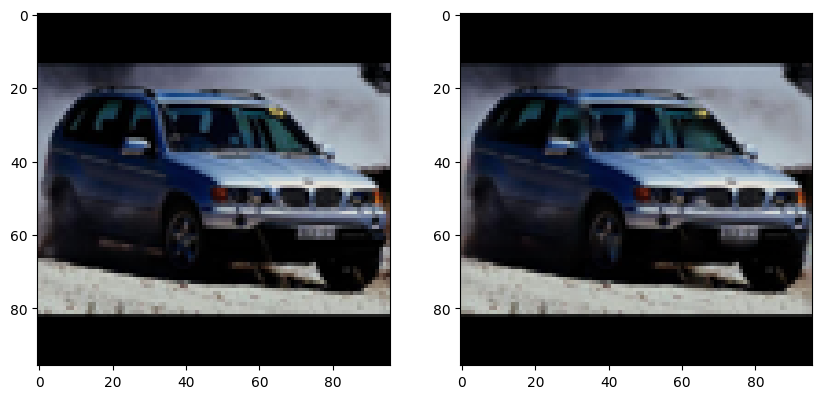

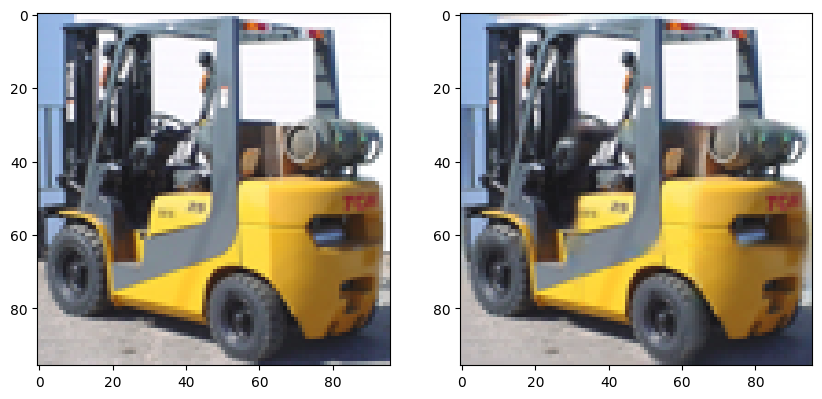

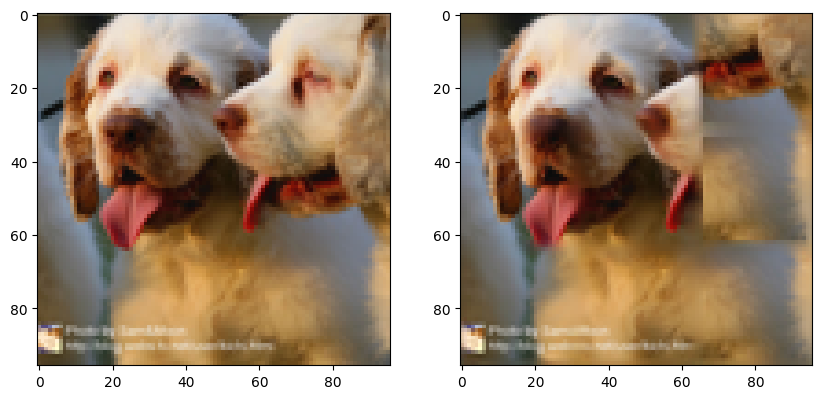

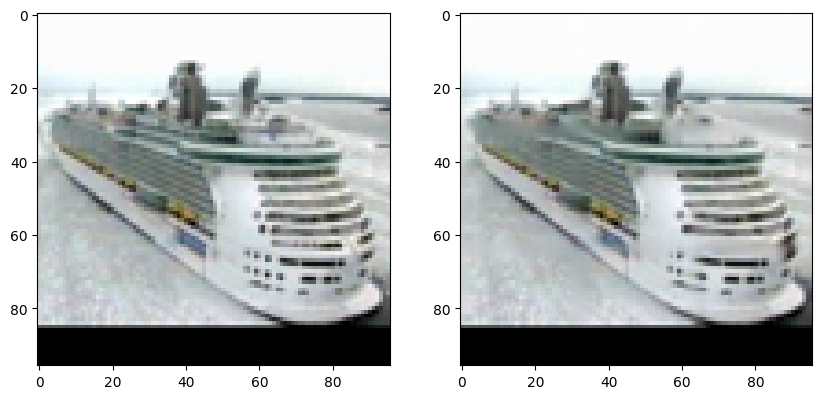

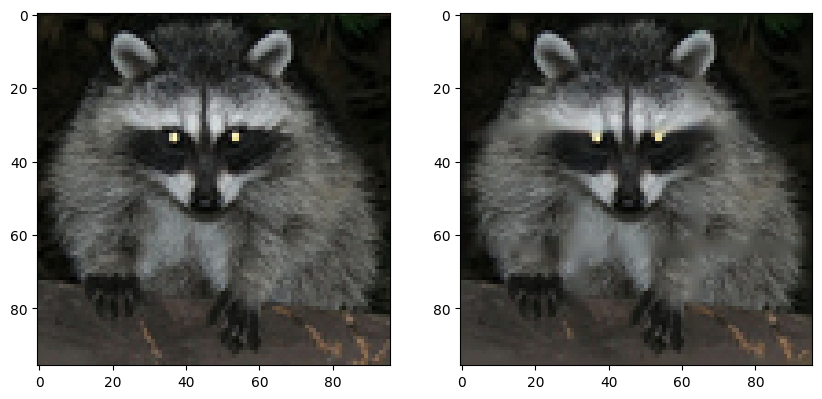

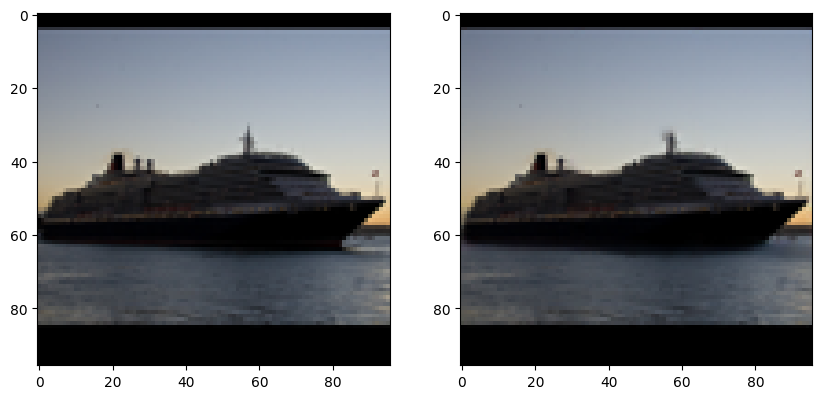

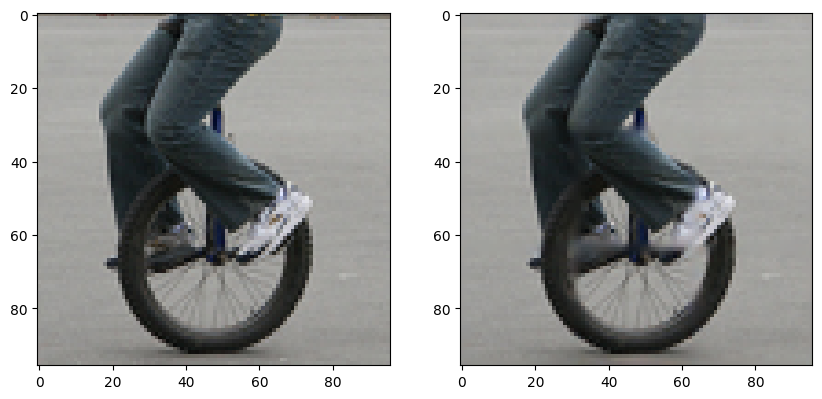

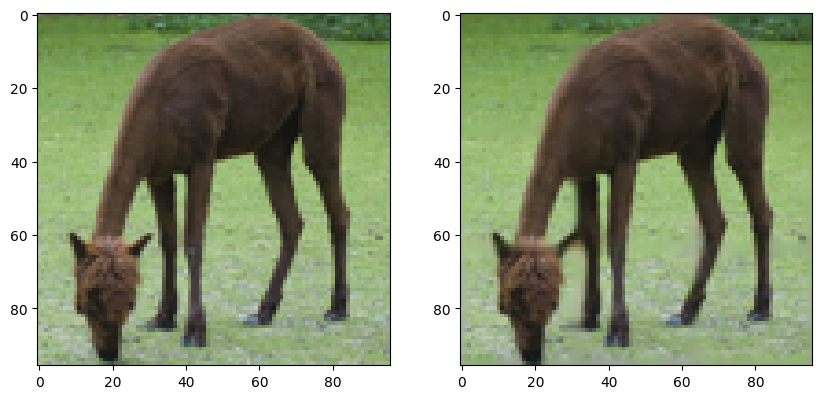

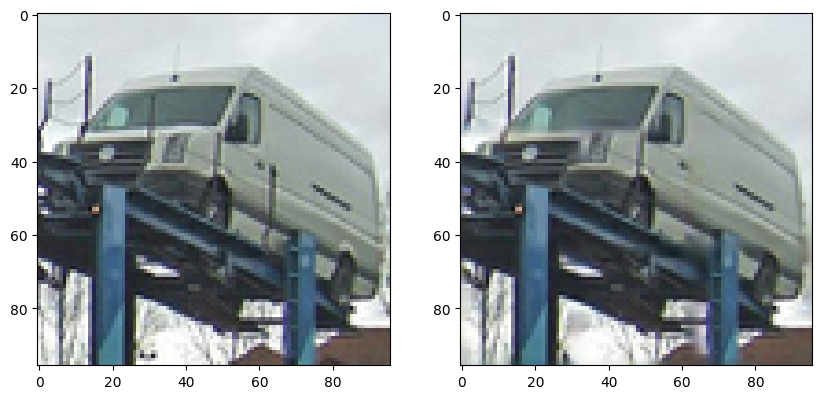

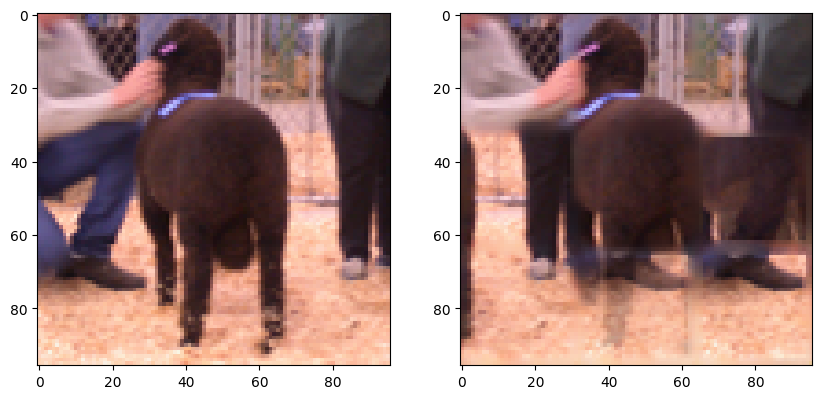

In [67]:
X, label_dict = test_generator[80]
Y  = label_dict["reconstruction"]
pred = model.predict(X, verbose=0)
recon = pred[0] if isinstance(pred, list) else pred["reconstruction"]
for i in range(10):
  idx = np.random.randint(0,len(X))
  fig, ax = plt.subplots(1, 2, figsize=(10, 5))
  ax[0].imshow(Y[idx])
  ax[1].imshow(recon[idx])

In [70]:
print("=" * 45)
print("         EVALUATION RESULTS")
print("=" * 45)
print(f"Baseline MAE      : {baseline_MAE:.5f}")
# print(f"Phase 1 MAE       : {Phase1_MAE:.5f}")
print(f"Final MAE         : {Final_MAE:.5f} ± {Final_std:.5f}")
print(f"Improvement       : {((baseline_MAE - Final_MAE) / baseline_MAE * 100):.1f}% over baseline")
print("-" * 45)
print(f"Trainable Params  : {model.count_params():,}")
print("=" * 45)

         EVALUATION RESULTS
Baseline MAE      : 0.18237
Final MAE         : 0.03006 ± 0.00102
Improvement       : 83.5% over baseline
---------------------------------------------
Trainable Params  : 3,439,572
